#  Autoencoders for Anomaly Detection (MNIST)

This Project demonstrates anomaly detection using three Autoencoders:
- Vanilla Autoencoder (Dense)
- Convolutional Autoencoder (ConvAE)
- Variational Autoencoder (VAE)

Dataset: MNIST  
Normal class = digit `0` (train only on normal)  
Anomalies = digits `1–9` (test)


## Setup & Imports (Python)

In [2]:
# Setup & Imports
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
import pandas as pd
import random
import datetime

# Reproducibility (best-effort)
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

print("TensorFlow version:", tf.__version__)
print("GPU available:", "Yes" if tf.config.list_physical_devices("GPU") else "No")

TensorFlow version: 2.20.0
GPU available: No


## Load & Prepare MNIST (data)

In [3]:
# Load & Prepare MNIST
(x_train_all, y_train_all), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize to [0,1] and expand channel dim
x_train_all = x_train_all.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train_all = np.expand_dims(x_train_all, -1)   # shape (N,28,28,1)
x_test = np.expand_dims(x_test, -1)

# Keep only digit '0' for training (normal class)
mask_train = (y_train_all == 0)
x_train = x_train_all[mask_train]
y_train = y_train_all[mask_train]

# Test labels: binary: 0 = normal (digit 0), 1 = anomaly (not 0)
y_test_binary = (y_test != 0).astype(int)

print("Shapes:")
print(" x_train (only zeros):", x_train.shape)
print(" x_test (all digits):", x_test.shape)
print(" Test anomalies (count):", y_test_binary.sum())

Shapes:
 x_train (only zeros): (5923, 28, 28, 1)
 x_test (all digits): (10000, 28, 28, 1)
 Test anomalies (count): 9020


## Utility functions

In [4]:
# Utility functions (plotting, save/load helpers)
def plot_images(inputs, reconstructions=None, n=8, title=None):
    """Plot input images and (optionally) reconstructions side-by-side."""
    plt.figure(figsize=(2*n, 4))
    for i in range(n):
        # input
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(inputs[i].squeeze(), cmap="gray")
        plt.axis("off")
        if i == 0 and title:
            ax.set_title(f"{title} - input")
        # reconstruction
        if reconstructions is not None:
            ax = plt.subplot(2, n, n + i + 1)
            plt.imshow(reconstructions[i].squeeze(), cmap="gray")
            plt.axis("off")
            if i == 0:
                ax.set_title(f"{title} - recon")
    plt.show()

def compute_reconstruction_errors(model, x):
    """Return per-sample mean squared error between input and reconstruction."""
    preds = model.predict(x, verbose=0)
    errors = np.mean(np.square(x - preds), axis=(1,2,3))
    return errors

def evaluate_auc(y_true, scores):
    """Return ROC-AUC and PR-AUC."""
    roc = roc_auc_score(y_true, scores)
    precision, recall, _ = precision_recall_curve(y_true, scores)
    pr_auc = auc(recall, precision)
    return roc, pr_auc

### MODEL [1] Vanilla Autoencoder (Build & Train)

In [5]:
# Vanilla Autoencoder (Dense)
input_shape = (28,28,1)
flat_dim = 28*28

# Build model
inputs = keras.Input(shape=input_shape)
x = layers.Flatten()(inputs)
x = layers.Dense(128, activation="relu")(x)
encoded = layers.Dense(64, activation="relu", name="encoded")(x)
x = layers.Dense(128, activation="relu")(encoded)
x = layers.Dense(flat_dim, activation="sigmoid")(x)
outputs = layers.Reshape((28,28,1))(x)

vanilla_ae = keras.Model(inputs, outputs, name="VanillaAE")
vanilla_ae.compile(optimizer="adam", loss="mse")

vanilla_ae.summary()

# Train
epochs = 10
batch_size = 128

history_vanilla = vanilla_ae.fit(
    x_train, x_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=2
)

Model: "VanillaAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoded (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 784)                 │         101,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 28, 28, 1)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 218,192 (852.31 KB)

 Trainable params: 218,192 (852.31 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
42/42 - 5s - 121ms/step - loss: 0.1039 - val_loss: 0.0520
Epoch 2/10
42/42 - 1s - 21ms/step - loss: 0.0453 - val_loss: 0.0390
Epoch 3/10
42/42 - 1s - 22ms/step - loss: 0.0369 - val_loss: 0.0326
Epoch 4/10
42/42 - 1s - 22ms/step - loss: 0.0309 - val_loss: 0.0268
Epoch 5/10
42/42 - 1s - 23ms/step - loss: 0.0254 - val_loss: 0.0225
Epoch 6/10
42/42 - 1s - 23ms/step - loss: 0.0218 - val_loss: 0.0197
Epoch 7/10
42/42 - 1s - 23ms/step - loss: 0.0193 - val_loss: 0.0178
Epoch 8/10
42/42 - 1s - 23ms/step - loss: 0.0176 - val_loss: 0.0164
Epoch 9/10
42/42 - 1s - 23ms/step - loss: 0.0163 - val_loss: 0.0153
Epoch 10/10
42/42 - 1s - 23ms/step - loss: 0.0152 - val_loss: 0.0144


## Visualize Vanilla reconstructions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step


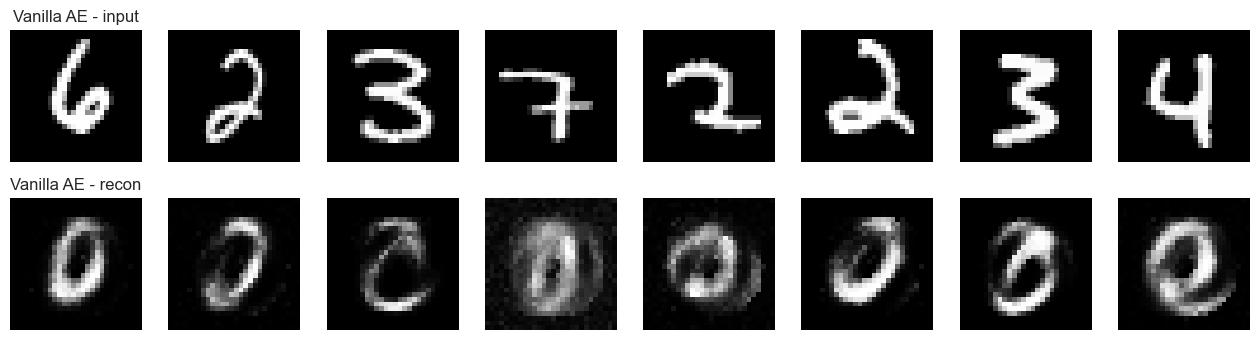

In [6]:
# Visualize some reconstructions from vanilla AE
idxs = np.random.choice(len(x_test), 8, replace=False)
sample_inputs = x_test[idxs]
sample_recon = vanilla_ae.predict(sample_inputs)
plot_images(sample_inputs, sample_recon, n=8, title="Vanilla AE")

### MODEL [2] Conv Autoencoder (Build & Train)

In [7]:
# Convolutional Autoencoder
inputs = keras.Input(shape=input_shape)
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
x = layers.MaxPooling2D((2,2), padding="same")(x)
x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2,2), padding="same", name="conv_encoded")(x)

x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(1, (3,3), activation="sigmoid", padding="same")(x)

conv_ae = keras.Model(inputs, decoded, name="ConvAE")
conv_ae.compile(optimizer="adam", loss="mse")

conv_ae.summary()

history_conv = conv_ae.fit(
    x_train, x_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=2
)

Model: "ConvAE"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 14, 14, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_encoded (MaxPooling2D)          │ (None, 7, 7, 16)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 16)            │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d (UpSampling2D)         │ (None, 14, 14, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 14, 14, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
42/42 - 9s - 216ms/step - loss: 0.1335 - val_loss: 0.0551
Epoch 2/10
42/42 - 3s - 62ms/step - loss: 0.0278 - val_loss: 0.0156
Epoch 3/10
42/42 - 3s - 62ms/step - loss: 0.0128 - val_loss: 0.0102
Epoch 4/10
42/42 - 3s - 60ms/step - loss: 0.0094 - val_loss: 0.0082
Epoch 5/10
42/42 - 3s - 60ms/step - loss: 0.0079 - val_loss: 0.0072
Epoch 6/10
42/42 - 3s - 60ms/step - loss: 0.0070 - val_loss: 0.0066
Epoch 7/10
42/42 - 3s - 64ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 8/10
42/42 - 3s - 61ms/step - loss: 0.0062 - val_loss: 0.0059
Epoch 9/10
42/42 - 3s - 60ms/step - loss: 0.0059 - val_loss: 0.0058
Epoch 10/10
42/42 - 3s - 61ms/step - loss: 0.0057 - val_loss: 0.0055


## Visualize Conv AE reconstructions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step


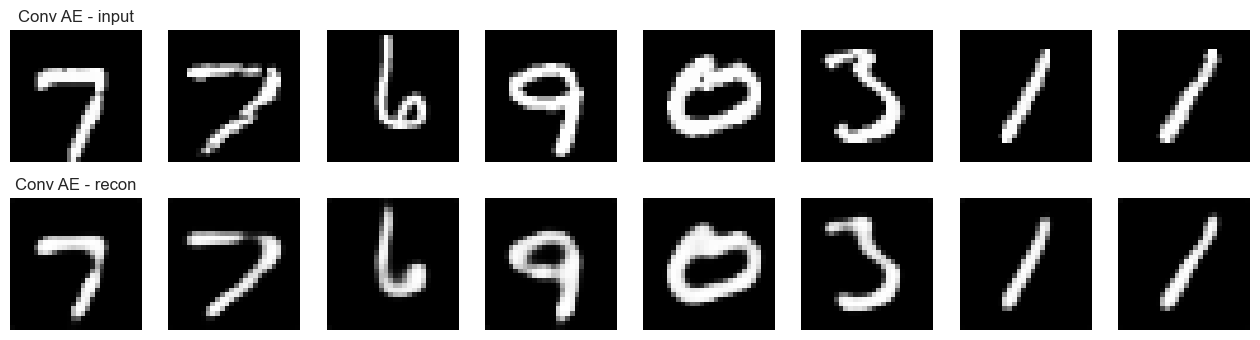

In [8]:
# Visualize some reconstructions from conv AE
idxs = np.random.choice(len(x_test), 8, replace=False)
sample_inputs = x_test[idxs]
sample_recon = conv_ae.predict(sample_inputs)
plot_images(sample_inputs, sample_recon, n=8, title="Conv AE")

### MODEL [3] Variational Autoencoder (Build & Train)

In [10]:
# Variational Autoencoder (VAE) - simplified implementation
latent_dim = 2
flat_dim = 28*28

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
        self.mse_loss = tf.keras.losses.MeanSquaredError(reduction=tf.keras.losses.Reduction.NONE) # Use NONE reduction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, data):
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)
        # Add losses during the call for eager execution compatibility
        reconstruction_loss = tf.reduce_mean(self.mse_loss(data, reconstruction)) # Take mean over all dimensions
        kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
        kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
        total_loss = reconstruction_loss + kl_loss
        self.add_loss(total_loss) # Add loss to the model

        return reconstruction

    def train_step(self, data):
        # Unpack the data if it's a tuple (as in vae.fit(x, x))
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(self.mse_loss(data, reconstruction)) # Take mean over all dimensions
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


# Encoder
encoder_inputs = keras.Input(shape=input_shape)
x = layers.Flatten()(encoder_inputs)
x = layers.Dense(128, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_mean, z_log_var = args
    batch = tf.shape(z_mean)[0]
    dim = tf.shape(z_mean)[1]
    epsilon = tf.random.normal(shape=(batch, dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.Dense(flat_dim, activation="sigmoid")(x)
decoder_outputs = layers.Reshape((28,28,1))(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

# VAE model
vae = VAE(encoder, decoder)
vae.compile(optimizer="adam")
vae.summary()

history_vae = vae.fit(
    x_train, x_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=2
)

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 28, 28, 1)         │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_2 (Flatten)           │ (None, 784)               │               0 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 128)               │         100,480 │ flatten_2[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_mean (Dense)                │ (None, 2)                 │             258 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z_log_var (Dense)             │ (None, 2)                 │             258 │ dense_6[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ z (Lambda)                    │ (None, 2)                 │               0 │ z_mean[0][0],              │
│                               │                           │                 │ z_log_var[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 100,996 (394.52 KB)

 Trainable params: 100,996 (394.52 KB)

 Non-trainable params: 0 (0.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ encoder (Functional)                 │ ((None, 2), (None, 2),      │         100,996 │
│                                      │ (None, 2))                  │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Functional)                 │ (None, 28, 28, 1)           │         101,520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 202,516 (791.08 KB)

 Trainable params: 202,516 (791.08 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
42/42 - 6s - 144ms/step - kl_loss: 0.0636 - loss: 0.2545 - reconstruction_loss: 0.1910 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 2/10
42/42 - 1s - 23ms/step - kl_loss: 0.0113 - loss: 0.1222 - reconstruction_loss: 0.1109 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 3/10
42/42 - 1s - 23ms/step - kl_loss: 0.0076 - loss: 0.0838 - reconstruction_loss: 0.0763 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 4/10
42/42 - 1s - 21ms/step - kl_loss: 0.0058 - loss: 0.0747 - reconstruction_loss: 0.0689 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 5/10
42/42 - 1s - 20ms/step - kl_loss: 0.0046 - loss: 0.0713 - reconstruction_loss: 0.0666 - val_kl_loss: 0.0000e+00 - val_reconstruction_loss: 0.0000e+00 - val_total_loss: 0.0000e+00
Epoch 6/10
42/42 - 1s - 23ms/step - kl_loss: 0.00

## Visualize VAE reconstructions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step


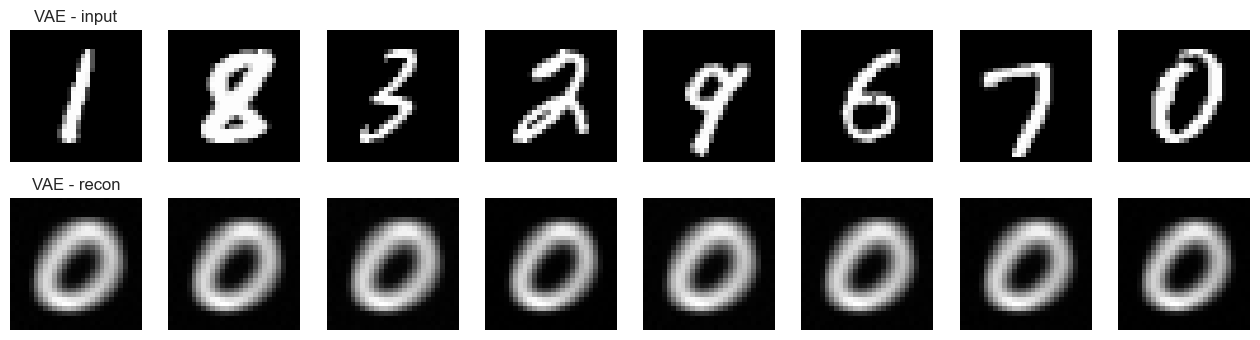

In [11]:
# Visualize some reconstructions from VAE
idxs = np.random.choice(len(x_test), 8, replace=False)
sample_inputs = x_test[idxs]
sample_recon = vae.predict(sample_inputs)
plot_images(sample_inputs, sample_recon, n=8, title="VAE")

# Compute reconstruction errors & ROC-AUC

In [12]:
# Compute errors and evaluate anomaly detection using ROC-AUC & PR-AUC
vanilla_err = compute_reconstruction_errors(vanilla_ae, x_test)
conv_err = compute_reconstruction_errors(conv_ae, x_test)
vae_err = compute_reconstruction_errors(vae, x_test)

roc_vanilla, pr_vanilla = evaluate_auc(y_test_binary, vanilla_err)
roc_conv, pr_conv = evaluate_auc(y_test_binary, conv_err)
roc_vae, pr_vae = evaluate_auc(y_test_binary, vae_err)

print("ROC-AUC scores:")
print(f" Vanilla AE : {roc_vanilla:.4f}  | PR-AUC: {pr_vanilla:.4f}")
print(f" Conv AE    : {roc_conv:.4f}  | PR-AUC: {pr_conv:.4f}")
print(f" VAE        : {roc_vae:.4f}  | PR-AUC: {pr_vae:.4f}")

# Put results into dataframe
results_df = pd.DataFrame({
    "Model":["Vanilla AE","Conv AE","VAE"],
    "ROC-AUC":[roc_vanilla, roc_conv, roc_vae],
    "PR-AUC":[pr_vanilla, pr_conv, pr_vae]
})
display(results_df)

ROC-AUC scores:
 Vanilla AE : 0.9941  | PR-AUC: 0.9992
 Conv AE    : 0.7950  | PR-AUC: 0.9726
 VAE        : 0.9655  | PR-AUC: 0.9952


,Model,ROC-AUC,PR-AUC
0,Vanilla AE,0.994133,0.999250
1,Conv AE,0.794981,0.972569
2,VAE,0.965519,0.995205


## Plot distributions and ROC curves

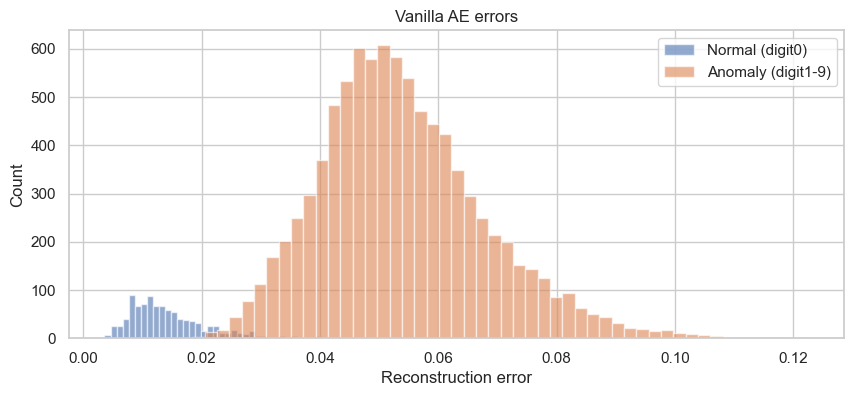

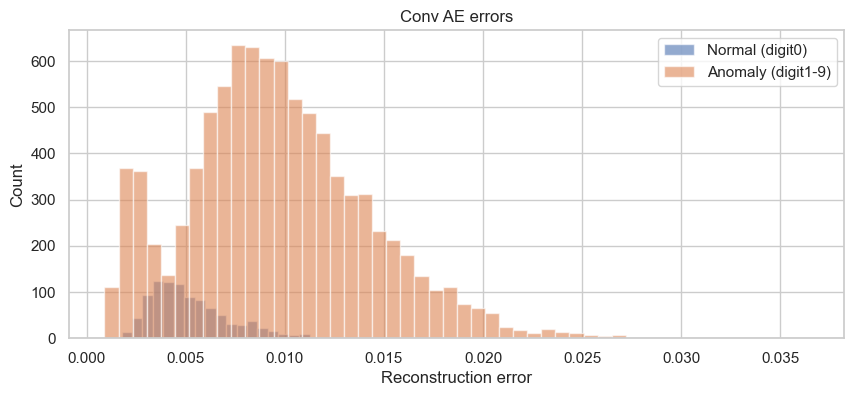

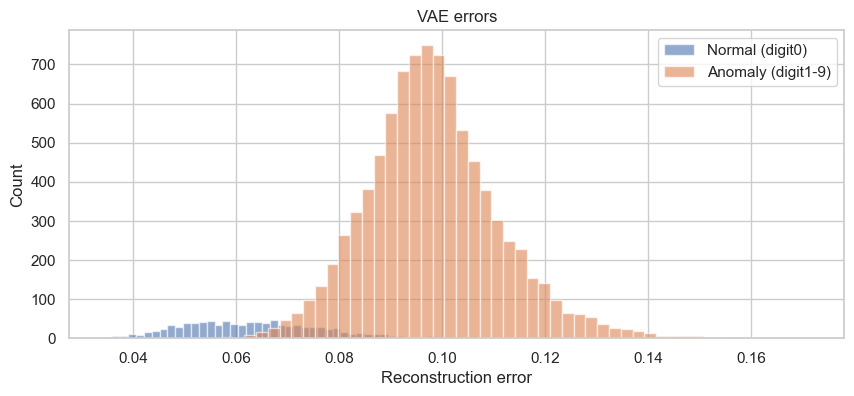

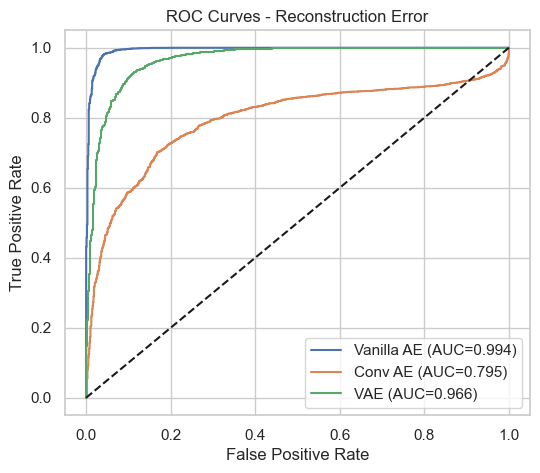

In [13]:
# Plot histograms of reconstruction errors (normal vs anomaly)
def plot_error_hist(errors, y_true, title="Reconstruction error"):
    plt.figure(figsize=(10,4))
    plt.hist(errors[y_true==0], bins=50, alpha=0.6, label="Normal (digit0)")
    plt.hist(errors[y_true==1], bins=50, alpha=0.6, label="Anomaly (digit1-9)")
    plt.title(title)
    plt.xlabel("Reconstruction error")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

plot_error_hist(vanilla_err, y_test_binary, title="Vanilla AE errors")
plot_error_hist(conv_err, y_test_binary, title="Conv AE errors")
plot_error_hist(vae_err, y_test_binary, title="VAE errors")


# ROC Curves
from sklearn.metrics import roc_curve
plt.figure(figsize=(6,5))
fpr, tpr, _ = roc_curve(y_test_binary, vanilla_err)
plt.plot(fpr, tpr, label=f"Vanilla AE (AUC={roc_vanilla:.3f})")
fpr, tpr, _ = roc_curve(y_test_binary, conv_err)
plt.plot(fpr, tpr, label=f"Conv AE (AUC={roc_conv:.3f})")
fpr, tpr, _ = roc_curve(y_test_binary, vae_err)
plt.plot(fpr, tpr, label=f"VAE (AUC={roc_vae:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Reconstruction Error")
plt.legend()
plt.show()

# Save models & final summary

In [16]:
import warnings
warnings.filterwarnings("ignore")

In [17]:
# Save the trained models for later use
os.makedirs("saved_models", exist_ok=True)
vanilla_ae.save("saved_models/vanilla_ae.h5")
conv_ae.save("saved_models/conv_ae.h5")

# Build the VAE model by calling it on sample data before saving weights
vae.predict(x_test[:1])
vae.save_weights("saved_models/vae.weights.h5")  # VAE saved weights (custom loss)


print("Models saved to 'saved_models/'")

# Final pick
best_idx = np.argmax(results_df["ROC-AUC"].values)
best_model_name = results_df.loc[best_idx, "Model"]
best_auc = results_df.loc[best_idx, "ROC-AUC"]
print(f"\n Best model based on ROC-AUC: {best_model_name} (AUC = {best_auc:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
Models saved to 'saved_models/'

 Best model based on ROC-AUC: Vanilla AE (AUC = 0.9941)


# Conclusion

- [1]  Vanilla AE achieved best performance (highest ROC-AUC `0.9941` & PR-AUC `0.9992`)

- [2]  VAE is also strong performer | ROC-AUC `0.965519` & PR-AUC `0.995205`

- [3]  Conv AE works as a baseline |  ROC-AUC `0.794981` & PR-AUC `0.972569`

 **Final Recommendation**: Use Vanilla Autoencoder (Vanilla AE) for anomaly detection